In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import cross_val_predict
import seaborn as sb
import random
import statsmodels.api as sm
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')

## Cargando el conjunto de datos

In [2]:
titanic = pd.read_csv("titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


El conjunto de datos tiene 891 filas y 12 variables. La variable respuesta que estaremos trabajando es "Survived" que indica si el pasajero sobrevivió (1) o no (0) al hundimiento del Titanic.

Lo primero que haremos será quitar del conjunto de datos aquellas variables que no se aportan información relevante para la elaboración de modelos como el id del pasajero, su nombre y su ticket.

In [3]:
titanic.shape

(891, 12)

In [4]:
titanic.drop(columns=["PassengerId","Name","Ticket"],axis=1, inplace=True)

In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


Del 78% de los datos se desconoce la cabina, así que vamos a quitar esta variable también.

In [6]:
titanic.drop(["Cabin"], axis=1, inplace=True)

In [7]:
titanic.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

In [8]:
print("Valores únicos de 'Sex':", titanic["Sex"].unique())
print("Valores únicos de 'Embarked':", titanic["Embarked"].unique())


Valores únicos de 'Sex': ['male' 'female']
Valores únicos de 'Embarked': ['S' 'C' 'Q' nan]


Codifiquemos las variables categóricas

In [9]:
titanic[["SexNum","EmbarkedNum"]]=titanic[['Sex', 'Embarked']].apply(lambda x: pd.factorize(x)[0])

Vamos a seleccionar las variables numéricas para hacer un modelo solo con ellas.

In [10]:
numericas = ["Age","SibSp","Parch", "Fare"]


Hagamos un resumen del conjunto de datos para ver si hay valores faltantes en algunas variables.

In [11]:
print(titanic.info())
titanic.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    object 
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Embarked     889 non-null    object 
 8   SexNum       891 non-null    int64  
 9   EmbarkedNum  891 non-null    int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 69.7+ KB
None


,Survived,Pclass,Age,SibSp,Parch,Fare,SexNum,EmbarkedNum
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.352413,0.359147
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.477990,0.638707
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000,0.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,2.000000


La edad tiene algunos valores faltantes, vamos rellenarlos con la mediana de la variable para no perder las filas.

In [12]:
titanic["Age"].fillna(np.nanmedian(titanic["Age"],), inplace=True)


/var/folders/9q/tfydcr6d56x3ht8bfg6vfx240000gn/T/ipykernel_45270/2269171947.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Age"].fillna(np.nanmedian(titanic["Age"],), inplace=True)


Separemos en Conjuntos de Entrenamiento (70%) y Prueba (30%) usando muestreo aleatorio simple.

In [13]:
y = titanic.pop("Survived")
X = titanic
X.drop(["Sex","Embarked"], axis=1, inplace=True)
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7)

In [14]:
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Hagamos ahora un modelo de regresión logística solo con las variables numéricas

| Solver    | Cuándo usarlo                            |
| --------- | ---------------------------------------- |
| liblinear | Binario, dataset pequeño                 |
| lbfgs     | Default, general, multiclase             |
| newton-cg | Similar a lbfgs                          |
| sag       | Dataset grande (solo l2)                 |
| saga      | Dataset grande + quieres l1 o elasticnet |


In [15]:
logReg = LogisticRegression(solver='liblinear')
result = logReg.fit(X_train[numericas],y_train)

In [16]:
y_pred = logReg.predict(X_test[numericas])
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logReg.score(X_test[numericas], y_test)))

Accuracy of logistic regression classifier on test set: 0.64


Veamos la matriz de confusión

              precision    recall  f1-score   support

           0       0.62      0.97      0.75       154
           1       0.81      0.19      0.31       114

    accuracy                           0.64       268
   macro avg       0.72      0.58      0.53       268
weighted avg       0.70      0.64      0.57       268



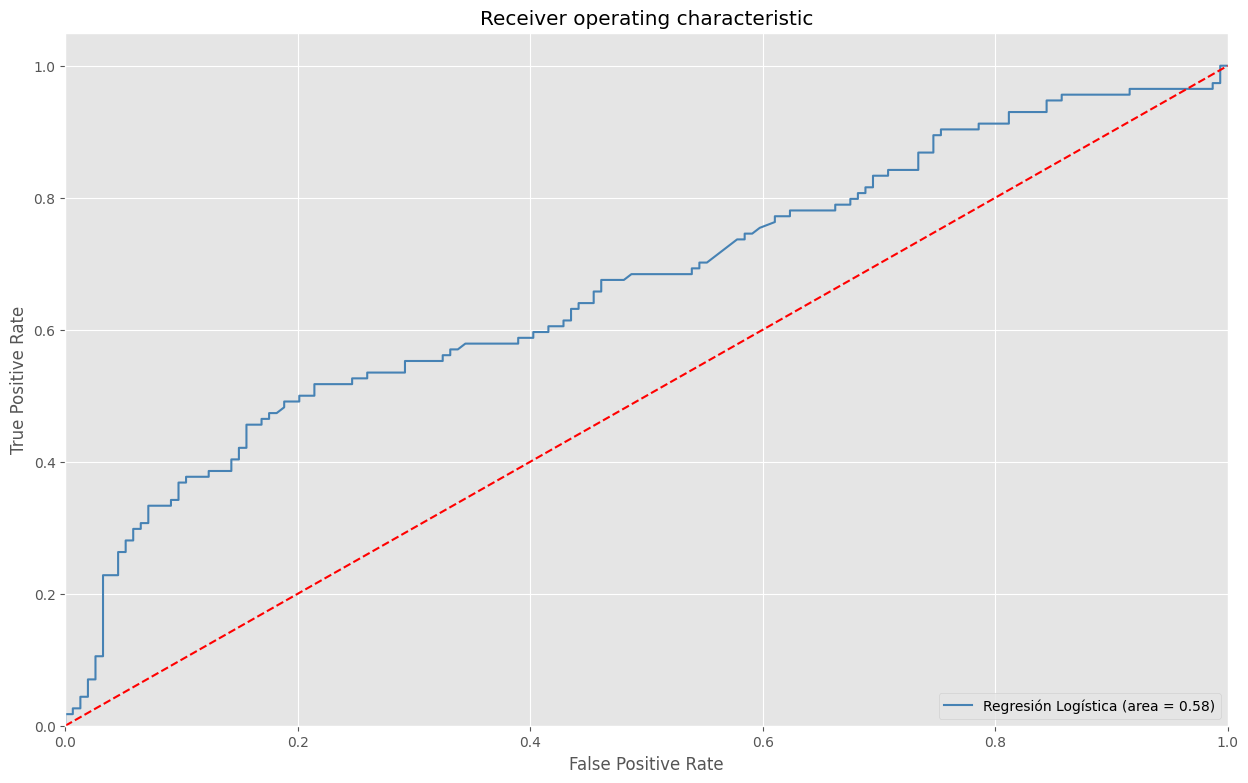

In [17]:
print(classification_report(y_test,y_pred))

logit_roc_auc = roc_auc_score(y_test, logReg.predict(X_test[numericas]))
fpr, tpr, thresholds = roc_curve(y_test, logReg.predict_proba(X_test[numericas])[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Regresión Logística (area = %0.2f)' % logit_roc_auc, color="steelblue")
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

Hagamos ahora un modelo usando validación cruzada con todas las variables.

In [18]:
solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=logReg, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X, y)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

In [19]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

best_model = grid_result.best_estimator_
print(grid_search)


Best: 0.803941 using {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
0.796105 (0.038277) with: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
0.796475 (0.037933) with: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.795730 (0.038094) with: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
0.795730 (0.038094) with: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.794607 (0.039377) with: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
0.795730 (0.039397) with: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
0.796101 (0.038838) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.796105 (0.040103) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.796109 (0.043591) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
0.798344 (0.039743) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
0.798348 (0.038761) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.803941 (0.043089) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
0.735897 (0.038730) wit

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       154
           1       0.82      0.68      0.74       114

    accuracy                           0.80       268
   macro avg       0.80      0.78      0.79       268
weighted avg       0.80      0.80      0.79       268



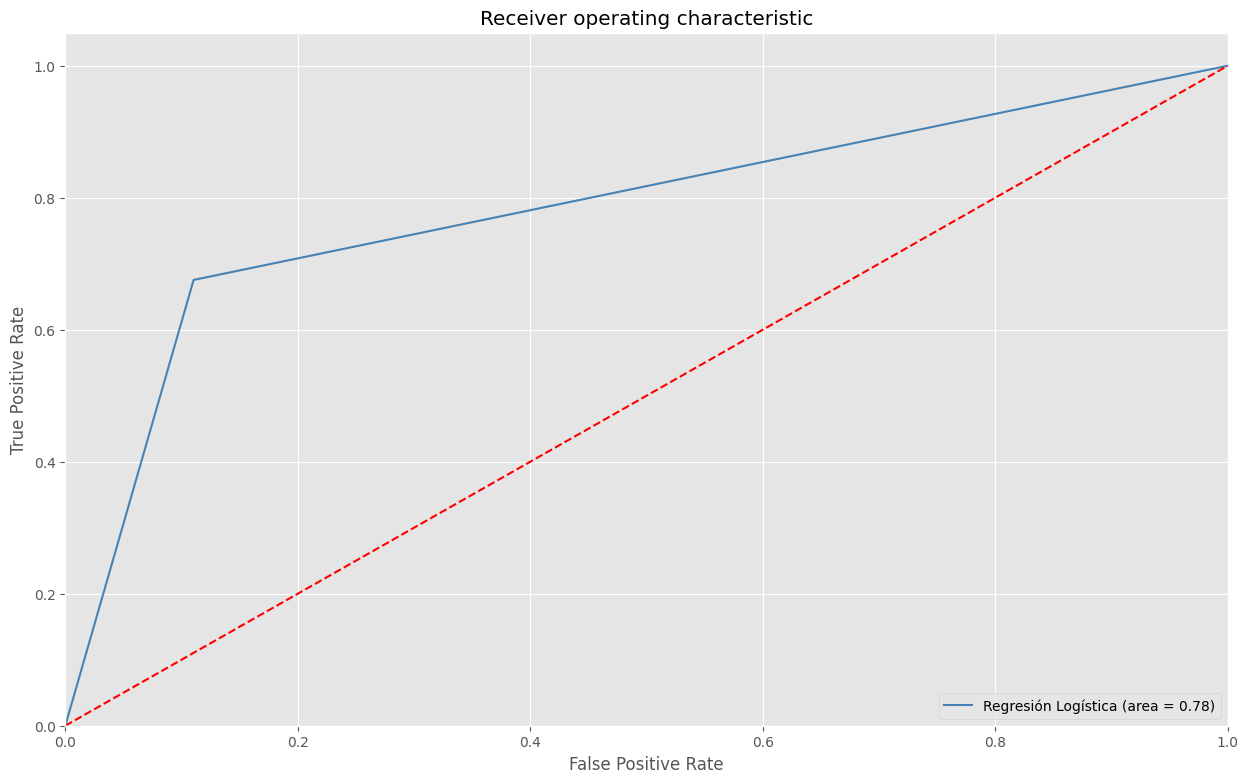

In [20]:
ypred = best_model.predict(X_test)
print(classification_report(y_test,ypred))

logit_roc_auc = roc_auc_score(y_test, ypred)
fpr, tpr, thresholds = roc_curve(y_test, ypred)
plt.figure()
plt.plot(fpr, tpr, label='Regresión Logística (area = %0.2f)' % logit_roc_auc, color="steelblue")
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

Usemos ahora regularización a ver si mejora

In [21]:
from sklearn.linear_model import RidgeClassifier
model = RidgeClassifier()
alpha = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
# define grid search
grid = dict(alpha=alpha)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X, y)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.796092 using {'alpha': 0.4}
0.795718 (0.042624) with: {'alpha': 0.1}
0.795718 (0.042624) with: {'alpha': 0.2}
0.795718 (0.042624) with: {'alpha': 0.3}
0.796092 (0.043277) with: {'alpha': 0.4}
0.796092 (0.043277) with: {'alpha': 0.5}
0.796092 (0.043277) with: {'alpha': 0.6}
0.796092 (0.043277) with: {'alpha': 0.7}
0.796092 (0.043277) with: {'alpha': 0.8}
0.796092 (0.043277) with: {'alpha': 0.9}
0.796092 (0.043277) with: {'alpha': 1.0}


              precision    recall  f1-score   support

           0       0.78      0.87      0.82       154
           1       0.79      0.68      0.73       114

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.78       268
weighted avg       0.79      0.79      0.78       268



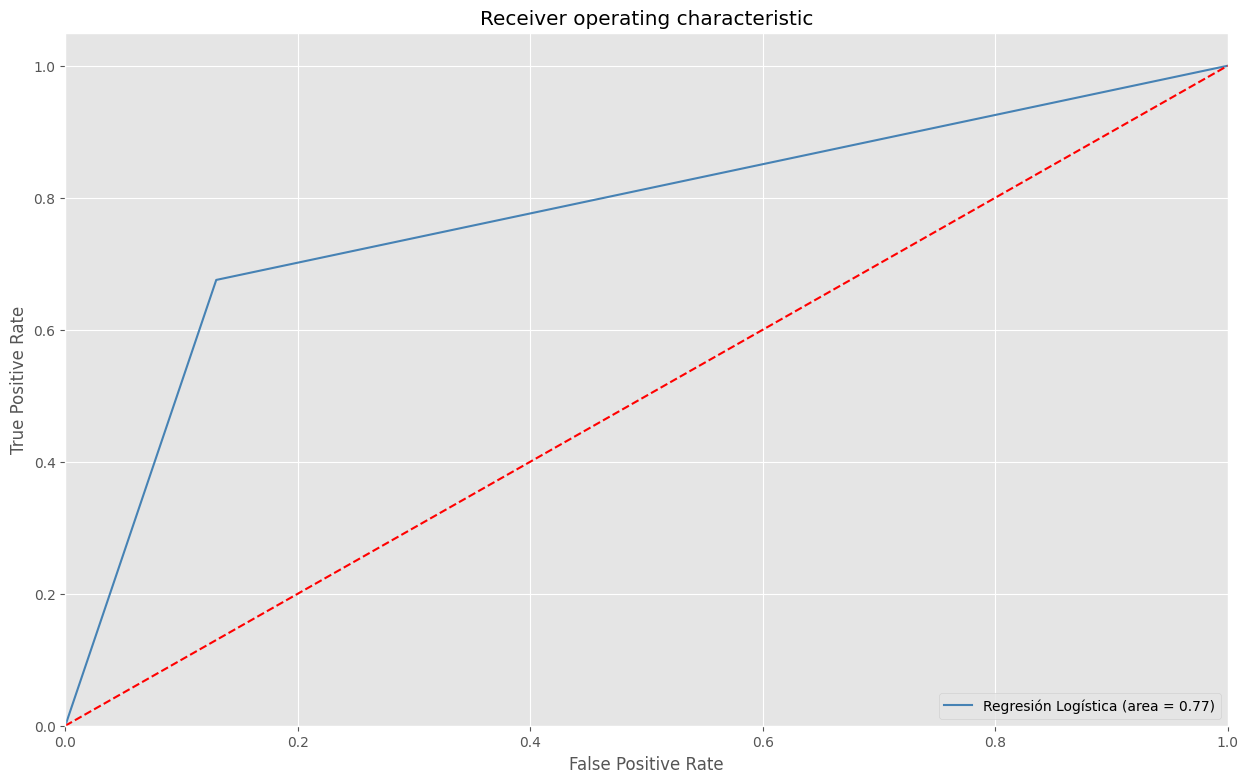

In [22]:
my_model = grid_result.best_estimator_
ypred2 = my_model.predict(X_test)
print(classification_report(y_test,ypred2))

logit_roc_auc = roc_auc_score(y_test, ypred2)
fpr, tpr, thresholds = roc_curve(y_test, ypred2)
plt.figure()
plt.plot(fpr, tpr, label='Regresión Logística (area = %0.2f)' % logit_roc_auc, color="steelblue")
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

Casi que no mejoró nada el modelo con el cambio de los hiperparámetros